In [1]:
import os
import sys
import math
import json
import glob
import argparse
import importlib
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import SIMPtools as st


In [2]:
# ---------------------------------------------------------------------------
# File Paths
# ---------------------------------------------------------------------------
# File path to 1% data file
data_1per_file = '/Users/mghrear/data/simp/1_percent_data/alldatabigroot.root' 

# Directory with signal MC files
signal_dir = '/Users/mghrear/data/simp/signal'

# Location of polynomial fit parameters for A(ctau_rho)
poly_fit_path = '/Users/mghrear/Desktop/2021/SIMP_signal/poly_fits.npz'

# ---------------------------------------------------------------------------
# Hit Categories
# ---------------------------------------------------------------------------
#hit_categories = ["isL1L1", "isL1L2", "isL2L2", "isL2L3"]
hit_categories = ["isL1L1", "isL1L2", "isL2L2"]

HITCAT_y0_REGIONS = {
    "isL1L1_lo": (0.24, 0.32),
    "isL1L2_lo": (0.30, 0.40),
    "isL2L2_lo": (0.20, 0.48),
    "isL2L3_lo": (0.44, 0.50),
    "isL1L1_hi": (0.32, np.inf),
    "isL1L2_hi": (0.40, np.inf),
    "isL2L2_hi": (0.48, np.inf),
    "isL2L3_hi": (0.50, np.inf),
}

# ---------------------------------------------------------------------------
# Grid definition
# ---------------------------------------------------------------------------
MASSES_MEV = np.arange(50, 275, 25, dtype=float)
EPSILONS   = np.logspace(math.log10(1e-4), math.log10(1e-2), 40)


# ---------------------------------------------------------------------------
# Data scaling
# ---------------------------------------------------------------------------
SIGNAL_DATA_SCALE = 100.0

In [3]:
# Load polynomial fit parameters for A(ctau_rho)
# There is one fit per A' mass
poly_data = np.load(poly_fit_path)
masses_loaded = poly_data['masses']   # shape (n_masses,)
coeffs_loaded = poly_data['coeffs']   # shape (n_masses, 8)

In [4]:
# Get \delta N_{bkg} / \delta m for all masses
nb_cache = st.compute_N_b_per_mass(root_files=[data_1per_file], masses_mev=MASSES_MEV, width_mev=1.0, SIGNAL_DATA_SCALE=SIGNAL_DATA_SCALE)

# Grid to store A' yield for each (epsilon, mass) pair
Ap_yield_grid = np.zeros((len(EPSILONS), len(MASSES_MEV)))

# Grid to store SIMP yield for each (epsilon, mass) at various stages for diagnostic plots
SIMP_yield_presel_grid = np.zeros((len(EPSILONS), len(MASSES_MEV)))
SIMP_yield_psum_grid = np.zeros((len(EPSILONS), len(MASSES_MEV)))
SIMP_yield_L1L1_grid = np.zeros((len(EPSILONS), len(MASSES_MEV)))
SIMP_yield_ProjSig_grid = np.zeros((len(EPSILONS), len(MASSES_MEV)))

# Grids to store final signal estimates
# One grid per (hit category, region) pair, e.g. SIMP_yield_final_grids["isL1L1_lo"]
SIMP_yield_final_grids = {
    f"{hitcat}_{region}": np.zeros((len(EPSILONS), len(MASSES_MEV)))
    for hitcat in hit_categories
    for region in ["lo", "hi"]
}


# Nested for loop over mass / epsilon grid
for i, mass in enumerate(MASSES_MEV):

    # Get \delta N_{bkg} / \delta m for this A' mass
    nb_signal = nb_cache[float(mass)]

    # Calculate dark sector masses and decay constant corresponding to this A' mass
    m_pi_D, m_V_D, f_pi_D = st.dark_masses(mass)

    # Calculate branching ratios for rho, and, phi
    # MG note: the final branching are not actually mass dependent, this can probably be taken out of the loop 
    rho_w   = st.width_Ap_to_vector(st.ALPHA_D, f_pi_D, m_pi_D, m_V_D, mass, 0.75)
    phi_w   = st.width_Ap_to_vector(st.ALPHA_D, f_pi_D, m_pi_D, m_V_D, mass, 1.5)
    invis_w = st.width_Ap_to_invis(st.ALPHA_D, m_pi_D, m_V_D, mass)
    charg_w = st.width_Ap_to_charged(st.ALPHA_D, f_pi_D, m_pi_D, m_V_D, mass)
    total_w      = rho_w + phi_w + invis_w + charg_w
    rho_fraction = rho_w / total_w
    phi_fraction = phi_w / total_w

    # Load preselection-level event info
    events = st._events_cache(m_V_D, signal_dir)
    # True vertex positions
    z_ev    = np.asarray(events["true_vd.vtx_z_"], dtype=np.float64)
    z_ev = z_ev + 1.1 # Account for target position
    # Recon Psum (used for Psum tight-selection)
    psum_ev = np.asarray(events["psum"],            dtype=np.float64)
    # Truth Psum (used for event weighting)
    truth_psum_ev = np.sqrt(events["true_vd.pz_"]**2+events["true_vd.px_"]**2+events["true_vd.py_"]**2)
    ele_z0  = np.asarray(events["ele.track_.z0_"],  dtype=np.float64)
    pos_z0  = np.asarray(events["pos.track_.z0_"],  dtype=np.float64)
    s_proj  = np.asarray(events["vtx_proj_sig"],    dtype=np.float64)
    invM_ev = np.asarray(events["vertex.invM_"],    dtype=np.float64)

    # compute min(|y0|), used for tigh-selection
    miny0 =np.min([np.abs(ele_z0),np.abs(pos_z0)],axis=0)

    # Calculate truth gamma and z, used to weight events
    gamma_ev     = 1000.0 * truth_psum_ev / m_V_D
    z_clipped    = np.where(z_ev >= 0, z_ev, 0.0)

    # MC sanity mask, true vertex must be beyond target
    mask_vtxz = z_ev >= 0
    # Psum tight-selection mask
    mask_psum = (psum_ev >= 1.5) & (psum_ev <= 3.0)
    # Projected significance tight-selection mask
    mask_proj = (s_proj < st.PROJ_SIG_CUT)
    
    for j, epsilon in enumerate(EPSILONS):

        # Get the A' yield for this (epsilon, mass) pair
        aprime_yield = nb_signal * 3.0 * math.pi / (2.0 * 1.0 * st.ALPHA_QED) * st.f_rad(mass) * mass * epsilon**2
        Ap_yield_grid[j, i] = aprime_yield

        # Get the decay lengths for rho and phi for this (epsilon, mass) pair
        rho_Gamma  = st.rate_2l(st.ALPHA_D, f_pi_D, m_pi_D, m_V_D, mass, epsilon, 0.511, True)
        phi_Gamma  = st.rate_2l(st.ALPHA_D, f_pi_D, m_pi_D, m_V_D, mass, epsilon, 0.511, False)
        rho_length = (1000 * st.HBAR_C * 10.0) / rho_Gamma # proper decay length in mm
        phi_length = (1000 * st.HBAR_C * 10.0) / phi_Gamma # proper decay length in mm

        # Look up A(ctau_rho) coefficients for this A' mass
        idx = np.where(masses_loaded == mass)[0][0]
        coeffs = coeffs_loaded[idx]

        # Calculate the expected number of SIMPs for this (epsilon, mass) pair after preselection
        # This factors in branching ratios as well as a Sarah-style prompt and displaced acceptance calculations
        acc_yield = aprime_yield * np.polyval(coeffs, np.log10(rho_length))
        SIMP_yield_presel_grid[j, i] = acc_yield

        # MG note: the final 'visible branching ratios' are not actually mass dependent, this can probably be taken out of the loop 
        tot_frac     = rho_fraction + phi_fraction
        rho_frac_vis = rho_fraction / tot_frac
        phi_frac_vis = phi_fraction / tot_frac

        # weight the events in the signal file using truth gamma and z
        # weight includes a contribution for rho and phi
        p_accept = (
            rho_frac_vis * np.exp(-z_clipped / (gamma_ev * rho_length)) / (rho_length * gamma_ev)
        + phi_frac_vis * np.exp(-z_clipped / (gamma_ev * phi_length)) / (phi_length * gamma_ev)
        )

        # Calcualte Sarah's weight scaling factor
        F_sarah = acc_yield / np.sum(p_accept)

        # Rescale the weights
        # Now signal estimation is "cut-and-count"
        p_accept *= F_sarah

        # I use these as sanity checks
        SIMP_yield_psum_grid[j, i] = np.sum(p_accept[ mask_vtxz & mask_psum ]) 
        SIMP_yield_L1L1_grid[j, i] = np.sum(p_accept[ mask_vtxz & mask_psum & np.asarray(events["isL1L1"], dtype=bool) ]) 
        SIMP_yield_ProjSig_grid[j, i] = np.sum(p_accept[ mask_vtxz & mask_psum & np.asarray(events["isL1L1"], dtype=bool) & mask_proj ]) 

        # Find signal yield for each hit category
        for hitcat in hit_categories:

            # Hit Category Selection
            hitmask =  np.asarray(events[hitcat], dtype=bool)

            # Apply ABCD mass window selection $|m_{e^+e^-} - m_0| \leq 1.7,\sigma(m_0)$
            # The mass resolution depends on hitcat
            mask_mass_window =  (( invM_ev > ((m_V_D - 1.7 * st.simp_mass_res(m_V_D, hitcat)) / 1000.0)) & 
                                 ( invM_ev < ((m_V_D + 1.7 * st.simp_mass_res(m_V_D, hitcat)) / 1000.0)))

            # Each hit category has its own "low" and "high" signal regions
            for region in ["lo","hi"]:

                # Min_y0 selection Selection
                mask_miny0 = (miny0 >HITCAT_y0_REGIONS[ hitcat+"_"+region ][0]) & (miny0 <= HITCAT_y0_REGIONS[hitcat+"_"+region][1])

                # Store final signal yield estimation
                SIMP_yield_final_grids[f"{hitcat}_{region}"][j, i] = np.sum(p_accept[ mask_vtxz & mask_psum & mask_proj & mask_mass_window & hitmask & mask_miny0])




  [loader] 0/1 files processed (0 ok, 0 skipped)...
  [loader] done: 1 files loaded, 0 skipped.


# Diagnostic plots

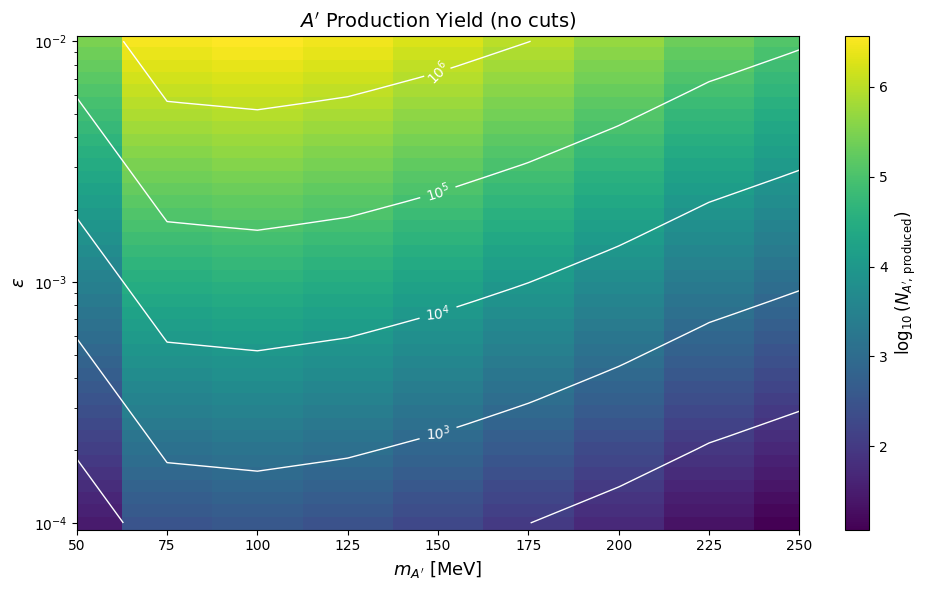

In [5]:

log_yield = np.log10(np.where(Ap_yield_grid > 0, Ap_yield_grid, np.nan))

fig, ax = plt.subplots(figsize=(10, 6))

pcm = ax.pcolormesh(
    MASSES_MEV, EPSILONS, log_yield,
    cmap="viridis",
    shading="auto",
)

contour_levels = [l for l in range(1, 7) if l <= np.nanmax(log_yield)]
cs = ax.contour(MASSES_MEV, EPSILONS, log_yield, levels=contour_levels, colors="white", linewidths=1.0)

# Place labels near x=150 MeV; interpolate exact epsilon for each level
i_ctr = np.argmin(np.abs(MASSES_MEV - 150.0))
col = log_yield[:, i_ctr]
valid = np.isfinite(col)
col_v, eps_v = col[valid], EPSILONS[valid]
label_pos = [
    (float(MASSES_MEV[i_ctr]), float(np.interp(l, col_v, eps_v)))
    for l in contour_levels if col_v.min() <= l <= col_v.max()
]
ax.clabel(cs, fmt=lambda x: f"$10^{{{int(round(x))}}}$", fontsize=10, inline=True, manual=label_pos)

ax.set_xlim(50, 250)
ax.set_xticks(MASSES_MEV[MASSES_MEV <= 250])
ax.set_yscale("log")
ax.set_xlabel(r"$m_{A'}$ [MeV]", fontsize=13)
ax.set_ylabel(r"$\varepsilon$", fontsize=13)
ax.set_title(r"$A'$ Production Yield (no cuts)", fontsize=14)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"$\log_{10}(N_{A',\,\mathrm{produced}})$", fontsize=12)

plt.tight_layout()
plt.show()


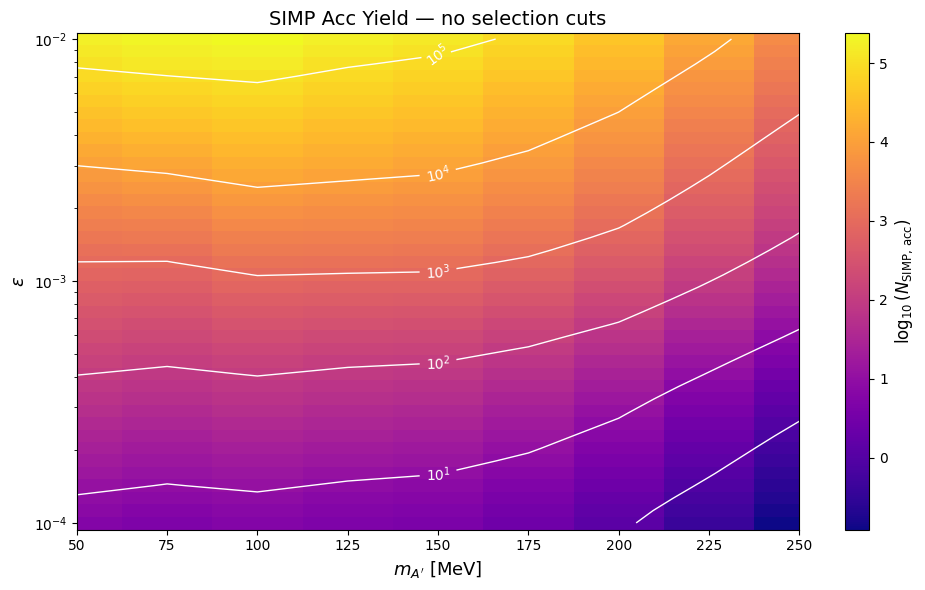

In [6]:

log_yield = np.log10(np.where(SIMP_yield_presel_grid > 0, SIMP_yield_presel_grid, np.nan))

fig, ax = plt.subplots(figsize=(10, 6))

pcm = ax.pcolormesh(
    MASSES_MEV, EPSILONS, log_yield,
    cmap="plasma",
    shading="auto",
)

lmin = -5
lmax = int(np.floor(np.nanmax(log_yield)))
all_levels = list(range(lmin, lmax + 1))

solid_levels  = [l for l in all_levels if l >= 0]
dashed_levels = [l for l in all_levels if l < 0]

fmt = lambda x: f"$10^{{{int(round(x))}}}$"

# Place labels near x=150 MeV; interpolate exact epsilon for each level so
# each position is precisely on its own contour and won't snap to a neighbour
i_ctr = np.argmin(np.abs(MASSES_MEV - 150.0))
col = log_yield[:, i_ctr]
valid = np.isfinite(col)
col_v, eps_v = col[valid], EPSILONS[valid]

def _label_pos(levels):
    return [
        (float(MASSES_MEV[i_ctr]), float(np.interp(l, col_v, eps_v)))
        for l in levels if col_v.min() <= l <= col_v.max()
    ]

if solid_levels:
    cs_s = ax.contour(MASSES_MEV, EPSILONS, log_yield, levels=solid_levels,
                      colors="white", linewidths=1.0, linestyles="solid")
    ax.clabel(cs_s, fmt=fmt, fontsize=10, inline=True, manual=_label_pos(solid_levels))

if dashed_levels:
    cs_d = ax.contour(MASSES_MEV, EPSILONS, log_yield, levels=dashed_levels,
                      colors="white", linewidths=1.0, linestyles="dashed")
    ax.clabel(cs_d, fmt=fmt, fontsize=10, inline=True, manual=_label_pos(dashed_levels))

ax.set_xlim(50, 250)
ax.set_xticks(MASSES_MEV[MASSES_MEV <= 250])
ax.set_yscale("log")
ax.set_xlabel(r"$m_{A'}$ [MeV]", fontsize=13)
ax.set_ylabel(r"$\varepsilon$", fontsize=13)
ax.set_title(r"SIMP Acc Yield — no selection cuts", fontsize=14)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"$\log_{10}(N_{\mathrm{SIMP,\,acc}})$", fontsize=12)

plt.tight_layout()
plt.show()


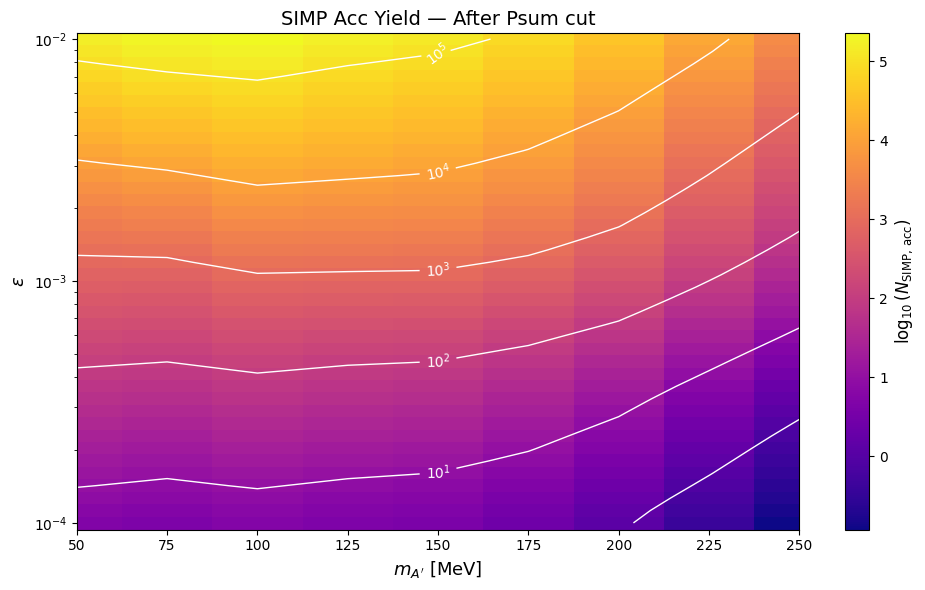

In [7]:

log_yield = np.log10(np.where(SIMP_yield_psum_grid > 0, SIMP_yield_psum_grid, np.nan))

fig, ax = plt.subplots(figsize=(10, 6))

pcm = ax.pcolormesh(
    MASSES_MEV, EPSILONS, log_yield,
    cmap="plasma",
    shading="auto",
)

lmin = -5
lmax = int(np.floor(np.nanmax(log_yield)))
all_levels = list(range(lmin, lmax + 1))

solid_levels  = [l for l in all_levels if l >= 0]
dashed_levels = [l for l in all_levels if l < 0]

fmt = lambda x: f"$10^{{{int(round(x))}}}$"

# Place labels near x=150 MeV; interpolate exact epsilon for each level so
# each position is precisely on its own contour and won't snap to a neighbour
i_ctr = np.argmin(np.abs(MASSES_MEV - 150.0))
col = log_yield[:, i_ctr]
valid = np.isfinite(col)
col_v, eps_v = col[valid], EPSILONS[valid]

def _label_pos(levels):
    return [
        (float(MASSES_MEV[i_ctr]), float(np.interp(l, col_v, eps_v)))
        for l in levels if col_v.min() <= l <= col_v.max()
    ]

if solid_levels:
    cs_s = ax.contour(MASSES_MEV, EPSILONS, log_yield, levels=solid_levels,
                      colors="white", linewidths=1.0, linestyles="solid")
    ax.clabel(cs_s, fmt=fmt, fontsize=10, inline=True, manual=_label_pos(solid_levels))

if dashed_levels:
    cs_d = ax.contour(MASSES_MEV, EPSILONS, log_yield, levels=dashed_levels,
                      colors="white", linewidths=1.0, linestyles="dashed")
    ax.clabel(cs_d, fmt=fmt, fontsize=10, inline=True, manual=_label_pos(dashed_levels))

ax.set_xlim(50, 250)
ax.set_xticks(MASSES_MEV[MASSES_MEV <= 250])
ax.set_yscale("log")
ax.set_xlabel(r"$m_{A'}$ [MeV]", fontsize=13)
ax.set_ylabel(r"$\varepsilon$", fontsize=13)
ax.set_title(r"SIMP Acc Yield — After Psum cut", fontsize=14)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"$\log_{10}(N_{\mathrm{SIMP,\,acc}})$", fontsize=12)

plt.tight_layout()
plt.show()


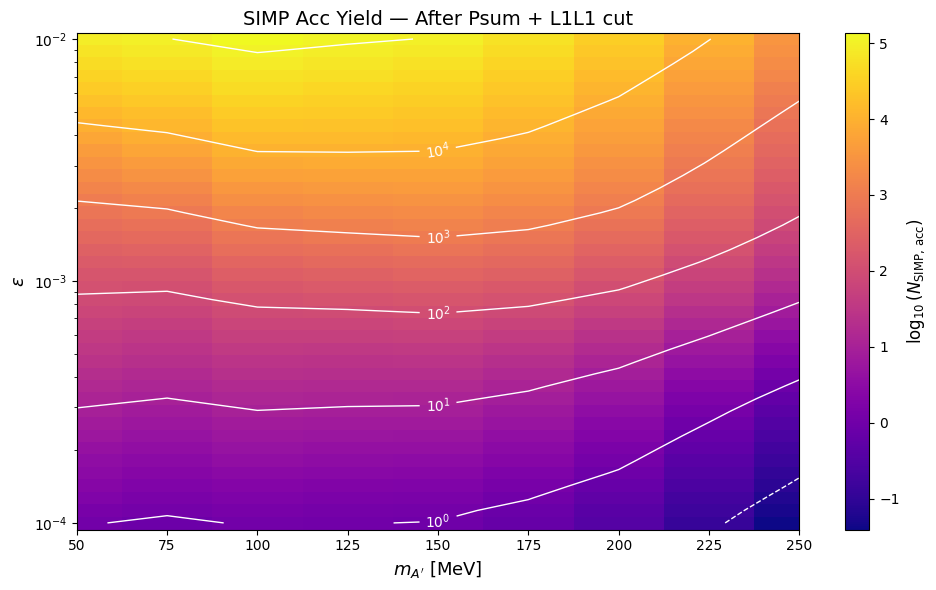

In [8]:

log_yield = np.log10(np.where(SIMP_yield_L1L1_grid > 0, SIMP_yield_L1L1_grid, np.nan))

fig, ax = plt.subplots(figsize=(10, 6))

pcm = ax.pcolormesh(
    MASSES_MEV, EPSILONS, log_yield,
    cmap="plasma",
    shading="auto",
)

lmin = -6
lmax = int(np.floor(np.nanmax(log_yield)))
all_levels = list(range(lmin, lmax + 1))

solid_levels  = [l for l in all_levels if l >= 0]
dashed_levels = [l for l in all_levels if l < 0]

fmt = lambda x: f"$10^{{{int(round(x))}}}$"

# Place labels near x=150 MeV; interpolate exact epsilon for each level so
# each position is precisely on its own contour and won't snap to a neighbour
i_ctr = np.argmin(np.abs(MASSES_MEV - 150.0))
col = log_yield[:, i_ctr]
valid = np.isfinite(col)
col_v, eps_v = col[valid], EPSILONS[valid]

def _label_pos(levels):
    return [
        (float(MASSES_MEV[i_ctr]), float(np.interp(l, col_v, eps_v)))
        for l in levels if col_v.min() <= l <= col_v.max()
    ]

if solid_levels:
    cs_s = ax.contour(MASSES_MEV, EPSILONS, log_yield, levels=solid_levels,
                      colors="white", linewidths=1.0, linestyles="solid")
    ax.clabel(cs_s, fmt=fmt, fontsize=10, inline=True, manual=_label_pos(solid_levels))

if dashed_levels:
    cs_d = ax.contour(MASSES_MEV, EPSILONS, log_yield, levels=dashed_levels,
                      colors="white", linewidths=1.0, linestyles="dashed")
    ax.clabel(cs_d, fmt=fmt, fontsize=10, inline=True, manual=_label_pos(dashed_levels))

ax.set_xlim(50, 250)
ax.set_xticks(MASSES_MEV[MASSES_MEV <= 250])
ax.set_yscale("log")
ax.set_xlabel(r"$m_{A'}$ [MeV]", fontsize=13)
ax.set_ylabel(r"$\varepsilon$", fontsize=13)
ax.set_title(r"SIMP Acc Yield — After Psum + L1L1 cut", fontsize=14)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"$\log_{10}(N_{\mathrm{SIMP,\,acc}})$", fontsize=12)

plt.tight_layout()
plt.show()


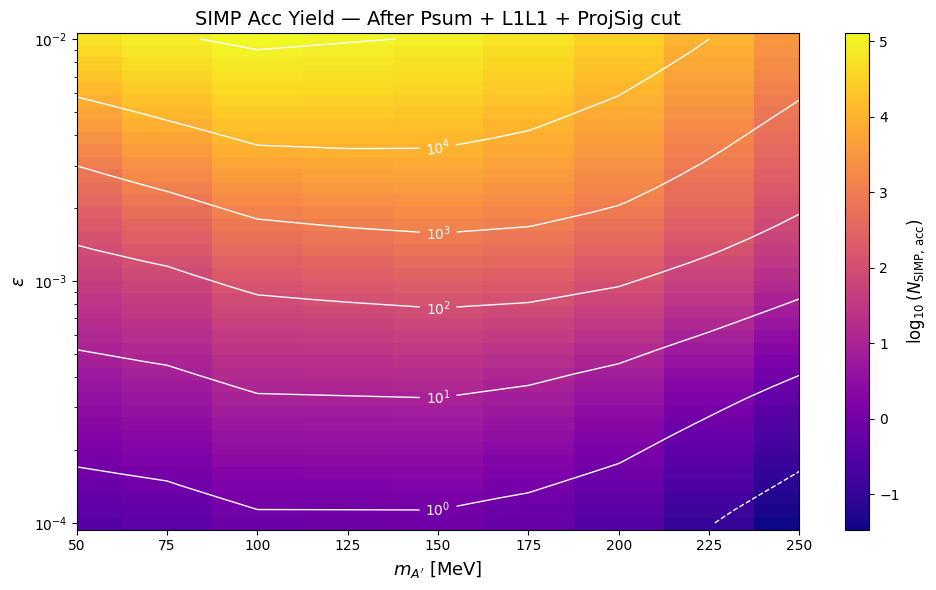

In [9]:

log_yield = np.log10(np.where(SIMP_yield_ProjSig_grid > 0, SIMP_yield_ProjSig_grid, np.nan))

fig, ax = plt.subplots(figsize=(10, 6))

pcm = ax.pcolormesh(
    MASSES_MEV, EPSILONS, log_yield,
    cmap="plasma",
    shading="auto",
)

lmin = -6
lmax = int(np.floor(np.nanmax(log_yield)))
all_levels = list(range(lmin, lmax + 1))

solid_levels  = [l for l in all_levels if l >= 0]
dashed_levels = [l for l in all_levels if l < 0]

fmt = lambda x: f"$10^{{{int(round(x))}}}$"

# Place labels near x=150 MeV; interpolate exact epsilon for each level so
# each position is precisely on its own contour and won't snap to a neighbour
i_ctr = np.argmin(np.abs(MASSES_MEV - 150.0))
col = log_yield[:, i_ctr]
valid = np.isfinite(col)
col_v, eps_v = col[valid], EPSILONS[valid]

def _label_pos(levels):
    return [
        (float(MASSES_MEV[i_ctr]), float(np.interp(l, col_v, eps_v)))
        for l in levels if col_v.min() <= l <= col_v.max()
    ]

if solid_levels:
    cs_s = ax.contour(MASSES_MEV, EPSILONS, log_yield, levels=solid_levels,
                      colors="white", linewidths=1.0, linestyles="solid")
    ax.clabel(cs_s, fmt=fmt, fontsize=10, inline=True, manual=_label_pos(solid_levels))

if dashed_levels:
    cs_d = ax.contour(MASSES_MEV, EPSILONS, log_yield, levels=dashed_levels,
                      colors="white", linewidths=1.0, linestyles="dashed")
    ax.clabel(cs_d, fmt=fmt, fontsize=10, inline=True, manual=_label_pos(dashed_levels))

ax.set_xlim(50, 250)
ax.set_xticks(MASSES_MEV[MASSES_MEV <= 250])
ax.set_yscale("log")
ax.set_xlabel(r"$m_{A'}$ [MeV]", fontsize=13)
ax.set_ylabel(r"$\varepsilon$", fontsize=13)
ax.set_title(r"SIMP Acc Yield — After Psum + L1L1 + ProjSig cut", fontsize=14)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"$\log_{10}(N_{\mathrm{SIMP,\,acc}})$", fontsize=12)

plt.tight_layout()
plt.show()


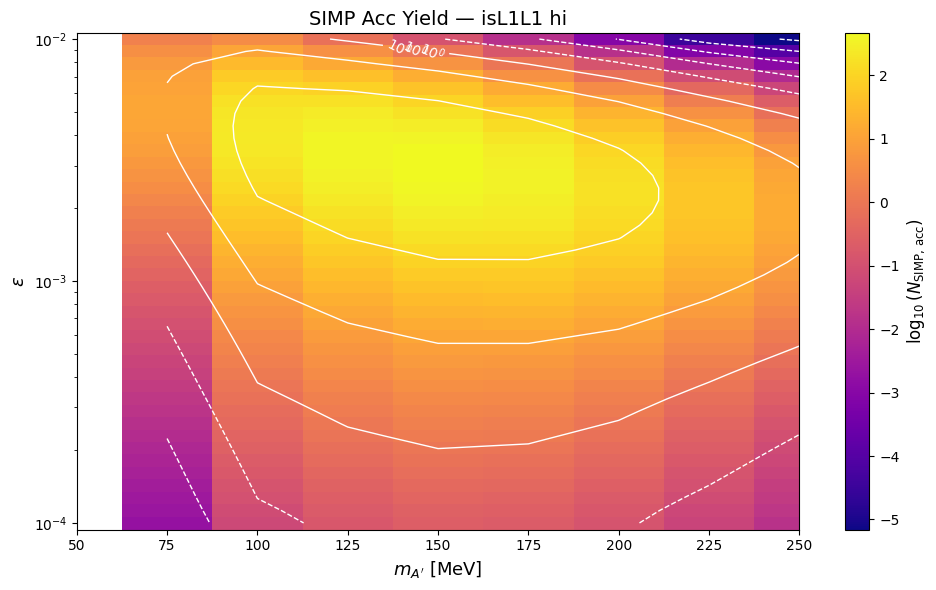

In [10]:
# ---------------------------------------------------------------------------
# Configure which grid to plot
PLOT_HITCAT = "isL1L1"   # one of: isL1L1, isL1L2, isL2L2, isL2L3
PLOT_REGION = "hi"       # "lo" or "hi"
# ---------------------------------------------------------------------------

key = f"{PLOT_HITCAT}_{PLOT_REGION}"
grid = SIMP_yield_final_grids[key]

log_yield = np.log10(np.where(grid > 0, grid, np.nan))

fig, ax = plt.subplots(figsize=(10, 6))

pcm = ax.pcolormesh(
    MASSES_MEV, EPSILONS, log_yield,
    cmap="plasma",
    shading="auto",
)

lmin = -6
lmax = int(np.floor(np.nanmax(log_yield))) if np.any(np.isfinite(log_yield)) else 0
all_levels = list(range(lmin, lmax + 1))

solid_levels  = [l for l in all_levels if l >= 0]
dashed_levels = [l for l in all_levels if l < 0]

fmt = lambda x: f"$10^{{{int(round(x))}}}$"

i_ctr = np.argmin(np.abs(MASSES_MEV - 150.0))
col = log_yield[:, i_ctr]
valid = np.isfinite(col)
col_v, eps_v = col[valid], EPSILONS[valid]

def _label_pos(levels):
    return [
        (float(MASSES_MEV[i_ctr]), float(np.interp(l, col_v, eps_v)))
        for l in levels if len(col_v) > 0 and col_v.min() <= l <= col_v.max()
    ]

if solid_levels:
    cs_s = ax.contour(MASSES_MEV, EPSILONS, log_yield, levels=solid_levels,
                      colors="white", linewidths=1.0, linestyles="solid")
    ax.clabel(cs_s, fmt=fmt, fontsize=10, inline=True, manual=_label_pos(solid_levels))

if dashed_levels:
    cs_d = ax.contour(MASSES_MEV, EPSILONS, log_yield, levels=dashed_levels,
                      colors="white", linewidths=1.0, linestyles="dashed")
    ax.clabel(cs_d, fmt=fmt, fontsize=10, inline=True, manual=_label_pos(dashed_levels))

ax.set_xlim(50, 250)
ax.set_xticks(MASSES_MEV[MASSES_MEV <= 250])
ax.set_yscale("log")
ax.set_xlabel(r"$m_{A'}$ [MeV]", fontsize=13)
ax.set_ylabel(r"$\varepsilon$", fontsize=13)
ax.set_title(rf"SIMP Acc Yield — {PLOT_HITCAT} {PLOT_REGION}", fontsize=14)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"$\log_{10}(N_{\mathrm{SIMP,\,acc}})$", fontsize=12)

plt.tight_layout()
plt.show()

# Data dump

The data is dumped into a Rory-style json file

In [13]:
# ---------------------------------------------------------------------------
# JSON export configuration
# ---------------------------------------------------------------------------
OUTPUT_HITCAT = "isL2L2"                # one of: isL1L1, isL1L2, isL2L2, isL2L3
OUTPUT_DIR    = "./signal_est/"         # directory to write the JSON file into

# ---------------------------------------------------------------------------


grid_lo = SIMP_yield_final_grids[f"{OUTPUT_HITCAT}_lo"]
grid_hi = SIMP_yield_final_grids[f"{OUTPUT_HITCAT}_hi"]

# Derive region bounds from HITCAT_y0_REGIONS
lo_bounds = HITCAT_y0_REGIONS[f"{OUTPUT_HITCAT}_lo"]   # (lo, hi)  e.g. (0.24, 0.32)
hi_bounds = HITCAT_y0_REGIONS[f"{OUTPUT_HITCAT}_hi"]   # (lo, inf) e.g. (0.32, inf)

# Build points list
points = []
for i, mass in enumerate(MASSES_MEV):
    for j, eps in enumerate(EPSILONS):
        S_lo = float(grid_lo[j, i])
        S_hi = float(grid_hi[j, i])
        if math.isfinite(S_lo) and math.isfinite(S_hi) and S_lo >= 0 and S_hi >= 0:
            points.append({
                "mass_MeV":        float(mass),
                "epsilon":         float(eps),
                "signal_regionlo": S_lo,
                "signal_regionhi": S_hi,
            })

points.sort(key=lambda d: (d["mass_MeV"], d["epsilon"]))

# Convert np.inf -> None so json.dump serialises it as null
def _bound(v):
    return None if not math.isfinite(v) else float(v)

z0_meta = {
    "lo": {"lo": _bound(lo_bounds[0]), "hi": _bound(lo_bounds[1])},
    "hi": {"lo": _bound(hi_bounds[0]), "hi": _bound(hi_bounds[1])},
}

output = {
    "metadata": {
        "hit_category":  OUTPUT_HITCAT,
        "Val2":          st.FIXED_VAL2,
        "proj_sig_cut":  st.PROJ_SIG_CUT,
        "z0_regions":    z0_meta,
        "mass_grid_MeV": MASSES_MEV.tolist(),
        "epsilon_grid":  EPSILONS.tolist(),
        "description": (
            f"Signal yields for two |z0| regions (hit-category specific). "
            f"Hit category: {OUTPUT_HITCAT}. "
            "Cut order: psum in [1.5,3.0], hit-category, "
            f"vtx_proj_sig < {st.PROJ_SIG_CUT}, then |z0| band. "
            f"Regions: lo=({lo_bounds[0]},{lo_bounds[1]}), "
            f"hi=({hi_bounds[0]},inf). "
            "signal_regionX = S_yield."
        ),
    },
    "n_points": len(points),
    "data":     points,
}

outfile = os.path.join(OUTPUT_DIR, f"results_{OUTPUT_HITCAT}_projSig_{st.PROJ_SIG_CUT:.4f}.json")
os.makedirs(OUTPUT_DIR, exist_ok=True)
with open(outfile, "w") as f:
    json.dump(output, f, indent=2)

print(f"Wrote {len(points)} points -> {outfile}")

Wrote 360 points -> ./signal_est/results_isL2L2_projSig_2.8000.json
